# Initialization

In [41]:
# Initialization
#import pyspark as spark
from pyspark.sql import SparkSession, functions

# incase the spark context already exists

spark = SparkSession \
        .builder \
        .appName("Project2") \
        .getOrCreate()


In [42]:
# Global Constants
random_seed = 42

path_to_file_local = "games_cleaned.csv"
path_to_file_hadoop = "hdfs://localhost:9000/steam-data/games_cleaned.csv"

In [43]:
from pyspark.sql.types import *


# TODO: Finish this... I'm too tired to finish this tonight
types = StructType([
    StructField('AppId', IntegerType(), True),
    StructField('Name', StringType(), True),
    StructField('Release date', StringType(), True),
    StructField('Estimated owners', StringType(), True),
    StructField('Peak CCU', IntegerType(), True),
    StructField('Required age', IntegerType(), True),
    StructField('Price', DoubleType(), True),
    StructField('DiscountDLC count', IntegerType(), True),
    StructField('Supported languages', StringType(), True),
    StructField('Full audio languages', StringType(), True),
    StructField('Windows', IntegerType(), True),
    StructField('Mac', IntegerType(), True),
    StructField('Linux', IntegerType(), True),
    StructField('Metacritic score', DoubleType(), True),
    StructField('User score', DoubleType(), True),
    StructField('Positive', IntegerType(), True),
    StructField('Negative', IntegerType(), True),
    StructField('Average playtime forever', DoubleType(), True),
    StructField('Average playtime two weeks', DoubleType(), True),
    StructField('Median playtime forever', DoubleType(), True),
    StructField('Median playtime two weeks', DoubleType(), True),
    StructField('Developers', StringType(), True),
    StructField('Publishers', StringType(), True), 
    StructField('Categories', StringType(), True),
    StructField('Genres', StringType(), True),
    StructField('Tags', StringType(), True),
    StructField('estimated_owners_mid', IntegerType(), True),
    StructField('estimated_revenue', DoubleType(), True),
    StructField('num_languages', DoubleType(), True)
])


data = spark.read.schema(types).csv(path_to_file_local, header=True)
data.show()

+-------+----------------------------+------------+----------------+--------+------------+-----+-----------------+--------------------+--------------------+-------+----+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------------+-------------+
|  AppId|                        Name|Release date|Estimated owners|Peak CCU|Required age|Price|DiscountDLC count| Supported languages|Full audio languages|Windows| Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|          Developers|          Publishers|          Categories|              Genres|                Tags|estimated_owners_mid|estimated_revenue|num_languages|
+-------+---------------------------

# Data Preparation

### Train Test Split

In [44]:
from pyspark.ml.feature import VectorAssembler

# Note: We probably need to translate some of the strings to integer enumerations...
# but until then....

string_columns = [c for c, t in data.dtypes if t == 'string']
#string_columns = [c.name for c in types.fields if c.typeName == 'str']
svm_data = data.drop(*string_columns)

assembler = VectorAssembler(
    inputCols=svm_data.columns,
    outputCol='features',
    handleInvalid='keep'
)

data_separeted = assembler.transform(svm_data.fillna(0) \
.withColumn('sold_well', functions.when(functions.col('estimated_revenue') >= 500000, 1).otherwise(0))
                                     ).drop('estimated_revenue')
data_separeted.show()

+-------+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+
|  AppId|Peak CCU|Required age|Price|DiscountDLC count|Windows|Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|estimated_owners_mid|num_languages|sold_well|            features|
+-------+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+
|2539430|       0|           0|  0.0|                0|      0|  0|    0|             0.0|       0.0|       0|       0|                 

In [45]:
train, test = data_separeted.randomSplit([0.7, 0.3], seed=random_seed)
train.show()

+-----+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+
|AppId|Peak CCU|Required age|Price|DiscountDLC count|Windows|Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|estimated_owners_mid|num_languages|sold_well|            features|
+-----+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+
|  420|      20|           0|  0.0|                0|      0|  0|    0|            90.0|       0.0|   40556|    1226|                     0.0|

In [46]:
# SVM for determining if a game will sell well
from pyspark.ml.classification import LinearSVC
svm = LinearSVC(labelCol='sold_well', featuresCol='features')

# default training
model =svm.fit(train)


In [47]:
prediction = model.transform(test)
prediction.show()


+-----+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+--------------------+----------+
|AppId|Peak CCU|Required age|Price|DiscountDLC count|Windows|Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|estimated_owners_mid|num_languages|sold_well|            features|       rawPrediction|prediction|
+-----+--------+------------+-----+-----------------+-------+---+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+-------------+---------+--------------------+--------------------+----------+
| 1250|     224|          17| 4.99|           

In [48]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

bcv = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', metricName='areaUnderROC')
auc = bcv.evaluate(prediction.withColumnRenamed("sold_well", "label"))
print(auc)


0.9999926374705883


# Revenue vs Positive Review Ratio - Linear Regression
**Problem Statement:** Is there a correlation between revenue and the ratio between the number of positive and negative reviews?

**Algorithm Choice - Why Linear Regression?**
The problem asks specifically about *correlation* between a continuous predictor (positive review ratio) and a continuous outcome (estimated revenue). Linear Regression because R² directly quantifies how much of the variance in revenue is explained by the ratio, and the slope coefficient tells us the direction and magnitude of the relationship. K-Means is already used to address the related problem of revenue vs. total review count. Linear Regression gives a third different model to run on the data that better fits this analysis(I think).

## Data Preparation
We compute positive_ratio (Positive / total reviews) as our feature and log_revenue (log-transformed estimated revenue) as our label. The log transform is necessary because revenue is extremely right-skewed — a handful of blockbuster titles would otherwise dominate the squared-error loss and make the model nearly meaningless for the majority of games. Games with zero revenue (free-to-play, no price signal) are filtered out, as are games with fewer than 10 total reviews — a game with 1 positive and 0 negative reviews has a ratio of 1.0 identical to a game with 10,000 positive reviews, which isjust added noise to the model rather than a signal. Requiring at least 10 reviews ensures the ratio is statistically meaningful.

In [49]:
from pyspark.ml.feature import VectorAssembler

lr_data = data \
    .filter((functions.col('Positive') + functions.col('Negative')) >= 10) \
    .filter(functions.col('estimated_revenue') > 0) \
    .withColumn('positive_ratio',
        functions.col('Positive') / (functions.col('Positive') + functions.col('Negative'))) \
    .withColumn('log_revenue', functions.log1p(functions.col('estimated_revenue')))

assembler = VectorAssembler(
    inputCols=['positive_ratio'],
    outputCol='features',
    handleInvalid='keep'
)

lr_data = assembler.transform(lr_data)
lr_data.show()

+-------+--------------------+------------+----------------+--------+------------+-----+-----------------+--------------------+--------------------+-------+----+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+-------------+------------------+------------------+--------------------+
|  AppId|                Name|Release date|Estimated owners|Peak CCU|Required age|Price|DiscountDLC count| Supported languages|Full audio languages|Windows| Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|          Developers|          Publishers|          Categories|              Genres|                Tags|estimated_owners_mid| estimated_revenue|num_la

In [50]:
train, test = lr_data.randomSplit([0.7, 0.3], seed=random_seed)

## Model Training — Baseline

In [51]:
# Linear Regression for determining correlation between
# positive review ratio and estimated revenue
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(labelCol='log_revenue', featuresCol='features')
model = lr.fit(train)

26/04/26 21:33:59 WARN Instrumentation: [e5118ce6] regParam is zero, which might cause numerical instability and overfitting.


In [52]:
prediction = model.transform(test)
prediction.show()

+-----+--------------------+------------+----------------+--------+------------+-----+-----------------+--------------------+--------------------+-------+----+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+-------------+------------------+------------------+--------------------+------------------+
|AppId|                Name|Release date|Estimated owners|Peak CCU|Required age|Price|DiscountDLC count| Supported languages|Full audio languages|Windows| Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|          Developers|          Publishers|          Categories|              Genres|                Tags|estimated_owners_mid| estimated

In [53]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol='log_revenue', predictionCol='prediction', metricName='rmse')
evaluator_r2   = RegressionEvaluator(labelCol='log_revenue', predictionCol='prediction', metricName='r2')

baseline_rmse = evaluator_rmse.evaluate(prediction)
baseline_r2   = evaluator_r2.evaluate(prediction)

print("--- Baseline ---")
print("RMSE: " + str(round(baseline_rmse, 4)))
print("R2:   " + str(round(baseline_r2, 4)))
print("Coefficient: " + str(round(model.coefficients[0], 4)))
print("Intercept:   " + str(round(model.intercept, 4)))

--- Baseline ---
RMSE: 1.7584
R2:   0.0101
Coefficient: 1.1585
Intercept:   10.4122


## Hyperparameter Tuning — Grid Search
We use ParamGridBuilder with TrainValidationSplit to perform a grid search over two parameters:
- **regParam** (λ): regularization strength. 0.0 = no regularization (plain OLS), higher values shrink the coefficient to reduce overfitting.
- **elasticNetParam** (α): controls the L1/L2 mix. 0.0 = Ridge, 1.0 = Lasso.

This gives 9 combinations (3 × 3). TrainValidationSplit evaluates each on an 80/20 internal split of the training data using RMSE and selects the best.

In [54]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam,        [0.0, 0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5,  1.0]) \
    .build()

tvs = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_rmse,
    trainRatio=0.8,
    seed=random_seed
)

best_model      = tvs.fit(train).bestModel
best_prediction = best_model.transform(test)

best_rmse = evaluator_rmse.evaluate(best_prediction)
best_r2   = evaluator_r2.evaluate(best_prediction)

print("--- Best Model (after grid search) ---")
print("regParam:        " + str(best_model.getRegParam()))
print("elasticNetParam: " + str(best_model.getElasticNetParam()))
print("RMSE: " + str(round(best_rmse, 4)))
print("R2:   " + str(round(best_r2, 4)))
print("Coefficient: " + str(round(best_model.coefficients[0], 4)))
print("Improvement in RMSE over baseline: " + str(round(baseline_rmse - best_rmse, 4)))

26/04/26 21:34:07 WARN Instrumentation: [3baf65d4] regParam is zero, which might cause numerical instability and overfitting.
26/04/26 21:34:10 WARN Instrumentation: [38cddf08] regParam is zero, which might cause numerical instability and overfitting.
26/04/26 21:34:11 WARN Instrumentation: [2892159a] regParam is zero, which might cause numerical instability and overfitting.


--- Best Model (after grid search) ---
regParam:        0.01
elasticNetParam: 0.5
RMSE: 1.7583
R2:   0.0102
Coefficient: 1.1279
Improvement in RMSE over baseline: 0.0001


## Analysis and Visualization
The scatter plot below shows each game in the test set as a point (positive_ratio vs log_revenue), with the fitted regression line overlaid. Steam games tend to cluster heavily toward high positive ratios (0.7–1.0), so expect a dense cloud on the right side. The Pearson correlation is reported as a model-free confirmation — if it agrees in sign with the regression coefficient, the linear relationship is genuine rather than a modeling artifact.

**Interpreting the results:** The R² value tells us directly how strong the correlation is. A positive coefficient means games with better review ratios tend to earn more revenue. However, a low R² (which is expected here — review ratio is just one of many factors that determine revenue) does not mean the correlation is absent; it means review quality alone is not a complete predictor of commercial success, which is itself an informative finding.

**An Interesting Result:** When run with ≥100 the grid search picked regParam=0.1, elasticNetParam=0.5 instead of no regularization. That means with the smaller, noisier dataset (>= 10) we actually needed to shrink the coefficient to avoid overfitting, which I guess shows the tuning doing exactly what it's supposed to.

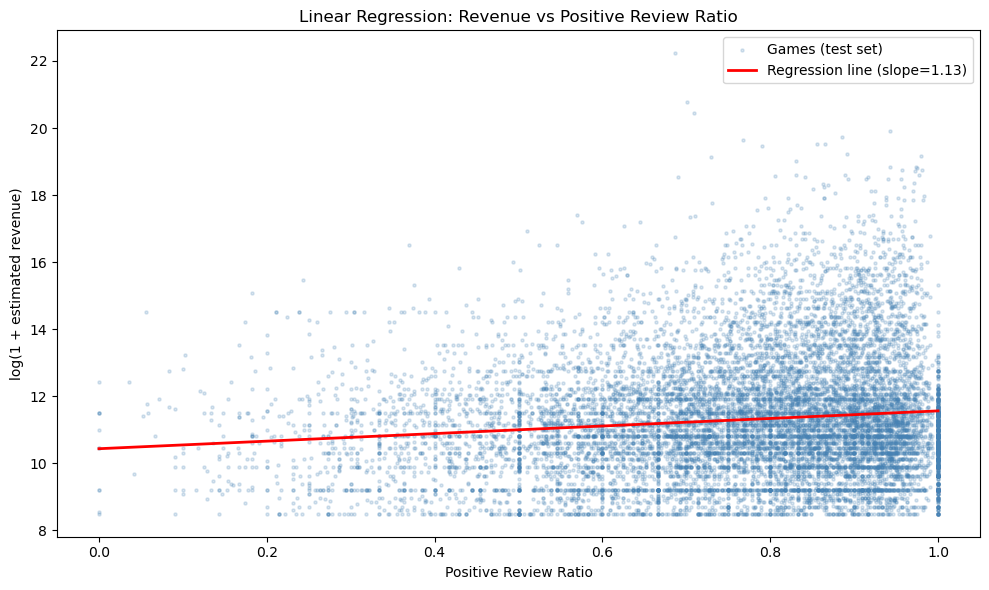

Pearson correlation: 0.1132
R2: 0.0102
The positive ratio explains 1.02% of variance in log revenue


In [55]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = best_prediction.select('positive_ratio', 'log_revenue', 'prediction').toPandas()

coeff     = best_model.coefficients[0]
intercept = best_model.intercept
x_line    = np.linspace(plot_df['positive_ratio'].min(), plot_df['positive_ratio'].max(), 200)
y_line    = coeff * x_line + intercept

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['positive_ratio'], plot_df['log_revenue'],
            alpha=0.2, s=5, color='steelblue', label='Games (test set)')
plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression line (slope=' + str(round(coeff, 2)) + ')')
plt.xlabel('Positive Review Ratio')
plt.ylabel('log(1 + estimated revenue)')
plt.title('Linear Regression: Revenue vs Positive Review Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('revenue_ratio_regression.png', dpi=120)
plt.show()

pearson = lr_data.stat.corr('positive_ratio', 'log_revenue')
print("Pearson correlation: " + str(round(pearson, 4)))
print("R2: " + str(round(best_r2, 4)))
print("The positive ratio explains " + str(round(best_r2 * 100, 2)) + "% of variance in log revenue")

# Revenue vs Number of Reviews - K-Means Clustering

## Data Preparation

In [56]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

km_data = data \
    .filter((functions.col('Positive') + functions.col('Negative')) > 0) \
    .filter(functions.col('estimated_revenue') > 0) \
    .withColumn('total_reviews', functions.col('Positive') + functions.col('Negative')) \
    .withColumn('log_revenue',   functions.log1p(functions.col('estimated_revenue'))) \
    .withColumn('log_reviews',   functions.log1p(functions.col('total_reviews')))

assembler = VectorAssembler(
    inputCols=['log_revenue', 'log_reviews'],
    outputCol='raw_features',
    handleInvalid='keep'
)
km_data = assembler.transform(km_data)

scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withMean=True,
    withStd=True
)
km_data = scaler.fit(km_data).transform(km_data)
km_data.show()

+-------+--------------------+------------+----------------+--------+------------+-----+-----------------+--------------------+--------------------+-------+----+-----+----------------+----------+--------+--------+------------------------+--------------------------+-----------------------+-------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+-------------+-------------+------------------+------------------+--------------------+--------------------+
|  AppId|                Name|Release date|Estimated owners|Peak CCU|Required age|Price|DiscountDLC count| Supported languages|Full audio languages|Windows| Mac|Linux|Metacritic score|User score|Positive|Negative|Average playtime forever|Average playtime two weeks|Median playtime forever|Median playtime two weeks|          Developers|          Publishers|          Categories|              Genres|                Tags|estimated_o

## Model Training

In [57]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator_silhouette = ClusteringEvaluator(featuresCol='features', metricName='silhouette')

kmeans = KMeans(featuresCol='features', predictionCol='prediction', k=2, seed=random_seed)
model = kmeans.fit(km_data)

prediction = model.transform(km_data)
silhouette = evaluator_silhouette.evaluate(prediction)

print("k: 2")
print("Silhouette: " + str(round(silhouette, 4)))
print("Cluster Sizes: " + str(model.summary.clusterSizes))
print("Cluster Centers (scaled):")
for c in model.clusterCenters():
    print("  " + str(c))

k: 2
Silhouette: 0.7416
Cluster Sizes: [53864, 13671]
Cluster Centers (scaled):
  [-0.35537158 -0.37951975]
  [1.4000424  1.49517791]


## Analysis and Visualization

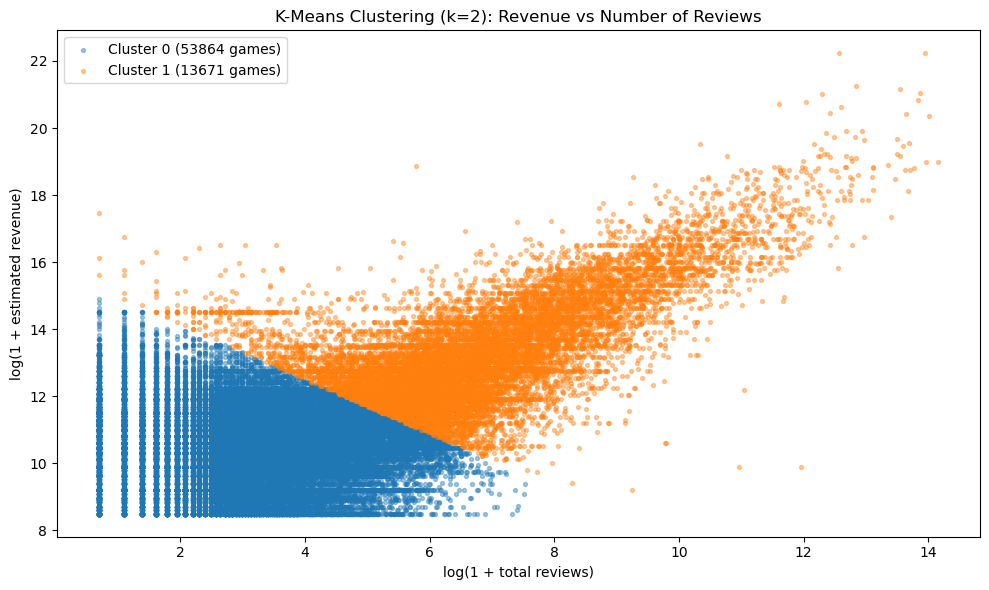

Overall Pearson correlation (log scale): 0.6262


Cluster 0: correlation=-0.0199, games=53864
Cluster 1: correlation=0.6429, games=13671


In [58]:
import matplotlib.pyplot as plt

plot_df = prediction.select('log_revenue', 'log_reviews', 'prediction').toPandas()
k = model.getK()

plt.figure(figsize=(10, 6))
for c in range(k):
    sub = plot_df[plot_df['prediction'] == c]
    plt.scatter(sub['log_reviews'], sub['log_revenue'],
                alpha=0.4, s=8,
                label='Cluster ' + str(c) + ' (' + str(len(sub)) + ' games)')
plt.xlabel('log(1 + total reviews)')
plt.ylabel('log(1 + estimated revenue)')
plt.title('K-Means Clustering (k=' + str(k) + '): Revenue vs Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('revenue_reviews_clusters.png', dpi=120)
plt.show()

overall_corr = prediction.stat.corr('log_revenue', 'log_reviews')
print("Overall Pearson correlation (log scale): " + str(round(overall_corr, 4)))

for c in range(k):
    cluster_subset = prediction.filter(functions.col('prediction') == c)
    cluster_corr   = cluster_subset.stat.corr('log_revenue', 'log_reviews')
    cluster_count  = cluster_subset.count()
    print("Cluster " + str(c) + ": correlation=" + str(round(cluster_corr, 4)) +
          ", games=" + str(cluster_count))

In [62]:
spark.stop()